<a href="https://colab.research.google.com/github/nassaigael/google_colab/blob/main/Analyse_Positionnement_HFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse du positionnement concurrentiel HFF
### Matériels divers, engins de chantier et véhicules — HS codes douaniers

**Demande** : analyse des données douanières (HS codes) pour ressortir le positionnement de HFF par rapport à ses concurrents, pour chaque marque/produit.
**Source de la demande** : email d'Aina Rajaonarivelo (HFF, `aina.rajaonarivelo@hff.mg`), 16/07/2026.

**Fichiers sources fournis :**
1. `HS_Code_Janv-Oct_2025_reorganise_1_.xlsx` — HS codes des matériels "divers" HFF (référentiel + déclarations douanières Jan-Oct 2025)
2. `Vehicules_Engins_Nov2025-Fev2026_reorganise.xlsx` — déclarations douanières Véhicules & Engins Nov 2025 - Fév 2026
3. `Imports_Jan2023-Jun2024_reorganise.xlsx` — base d'importations globales de Madagascar (marché, Jan 2023 - Juin 2024), utilisée comme contexte de marché

**Plan de l'analyse :**
0. Configuration et chargement des librairies
1. Chargement des données sources
2. Exploration des données (EDA)
3. Normalisation et harmonisation des données
4. Analyse du positionnement HFF vs concurrents
5. Visualisations
6. Génération du fichier résultat Excel
7. Synthèse et limites de l'analyse


## 0. Configuration et chargement des librairies

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_HFF = "#1A3C5E"
COLOR_CONCURRENT = "#FFC107"
COLOR_INCONNU = "#B0B0B0"
COLOR_MARCHE = "#5A8FC2"

DATA_DIR = Path("/content/drive/MyDrive/data")

FILE_HS2025 = DATA_DIR / "HS_CODE_2025.xlsx"
FILE_IMPORTS_2023_2024 = DATA_DIR / "IMPORT_2023_2024.xlsx"
FILE_VEHICULES = DATA_DIR / "VEHICULES_ENGINS_2025_2026.xlsx"

print("Fichiers sources :")
for f in [FILE_HS2025, FILE_IMPORTS_2023_2024, FILE_VEHICULES]:
    print(f" - {f.name} ({'OK' if f.exists() else 'MANQUANT'})")

Fichiers sources :
 - HS_CODE_2025.xlsx (OK)
 - IMPORT_2023_2024.xlsx (OK)
 - VEHICULES_ENGINS_2025_2026.xlsx (OK)


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Chargement des données sources

Chaque fichier source est chargé avec l'ensemble de ses feuilles :
- `HS_Code...xlsx` : `donnees_douanes` (déclarations) + `referentiel_hs_code` (catalogue HS codes / catégories HFF)
- `Vehicules...xlsx` : `donnees_douanes` (déclarations) + `codes_hs_suivis` (liste des HS codes suivis)
- `Imports...xlsx` : `imports` (base globale des importations malgaches, toutes marchandises)


In [35]:
try:
    # --- HS Code HFF "divers" (Janvier - Octobre 2025) ---
    raw_hs2025_douanes = pd.read_excel(FILE_HS2025, sheet_name="donnees_douanes")
    raw_hs2025_referentiel = pd.read_excel(FILE_HS2025, sheet_name="referentiel_hs_code")

    # --- Véhicules & Engins (Novembre 2025 - Février 2026) ---
    raw_veh_douanes = pd.read_excel(FILE_VEHICULES, sheet_name="donnees_douanes")
    raw_veh_codes_suivis = pd.read_excel(FILE_VEHICULES, sheet_name="codes_hs_suivis")

    # --- Marché global des importations (Janvier 2023 - Juin 2024) ---
    raw_imports_2023_2024 = pd.read_excel(FILE_IMPORTS_2023_2024, sheet_name="imports")

    print("donnees_douanes (HS 2025)      :", raw_hs2025_douanes.shape)
    print("referentiel_hs_code (HS 2025)  :", raw_hs2025_referentiel.shape)
    print("donnees_douanes (Vehicules)    :", raw_veh_douanes.shape)
    print("codes_hs_suivis (Vehicules)    :", raw_veh_codes_suivis.shape)
    print("imports (2023-2024)            :", raw_imports_2023_2024.shape)
except FileNotFoundError as e:
    print(f"Erreur: Le fichier n'a pas été trouvé. Veuillez vérifier le chemin: {e}")
    # Vous pouvez choisir de sortir ou de définir des DataFrames vides pour continuer
    raw_hs2025_douanes = pd.DataFrame()
    raw_hs2025_referentiel = pd.DataFrame()
    raw_veh_douanes = pd.DataFrame()
    raw_veh_codes_suivis = pd.DataFrame()
    raw_imports_2023_2024 = pd.DataFrame()
except ValueError as e:
    print(f"Erreur: Problème lors de la lecture du fichier Excel, possiblement une feuille manquante ou un format incorrect: {e}")
    raw_hs2025_douanes = pd.DataFrame()
    raw_hs2025_referentiel = pd.DataFrame()
    raw_veh_douanes = pd.DataFrame()
    raw_veh_codes_suivis = pd.DataFrame()
    raw_imports_2023_2024 = pd.DataFrame()
except Exception as e:
    print(f"Une erreur inattendue s'est produite lors du chargement des données: {e}")
    raw_hs2025_douanes = pd.DataFrame()
    raw_hs2025_referentiel = pd.DataFrame()
    raw_veh_douanes = pd.DataFrame()
    raw_veh_codes_suivis = pd.DataFrame()
    raw_imports_2023_2024 = pd.DataFrame()


donnees_douanes (HS 2025)      : (1368, 23)
referentiel_hs_code (HS 2025)  : (48, 4)
donnees_douanes (Vehicules)    : (486, 23)
codes_hs_suivis (Vehicules)    : (23, 1)
imports (2023-2024)            : (2915, 10)


## 2. Exploration des données (EDA)
### 2.1 Structure des jeux de données

In [36]:
print("=== Colonnes donnees_douanes (HS 2025) ===")
print(raw_hs2025_douanes.dtypes)
print()
print("=== Colonnes donnees_douanes (Vehicules) ===")
print(raw_veh_douanes.dtypes)
print()
print("=== Colonnes imports (2023-2024) ===")
print(raw_imports_2023_2024.dtypes)


=== Colonnes donnees_douanes (HS 2025) ===
reg_date                   datetime64[ns]
reg_year                            int64
month                               int64
sh_code                             int64
description_marchandise            object
itm_nber                          float64
net_weight_kg                     float64
gross_weight_kg                   float64
number_of_units                   float64
pack_number                         int64
amount_ariary                       int64
FOBDEVISE                         float64
DEVISE                             object
TAUXCHANGE                        float64
DD                                float64
TVA                               float64
regime_code                        object
regime_libelle                     object
provenance_code                    object
provenance_libelle                 object
origine_code                       object
origine_libelle                    object
flag                             

### 2.2 Valeurs manquantes et signification du champ `flag`

Le champ `flag` des fichiers douaniers HFF est la clé de l'analyse concurrentielle : il indique
si une déclaration douanière a été identifiée comme provenant de HFF (`1`), d'un concurrent (`0`),
ou n'a pas encore été identifiée (valeur manquante). C'est ce marquage manuel qui permet de
distinguer HFF de ses concurrents, les données douanières brutes ne portant pas le nom de
l'opérateur.


In [37]:
def missing_report(df, name):
    m = df.isna().sum()
    m = m[m > 0].sort_values(ascending=False)
    if len(m) == 0:
        print(f"[{name}] Aucune valeur manquante.")
    else:
        print(f"[{name}] Valeurs manquantes :")
        print(m)
    print()

missing_report(raw_hs2025_douanes, "HS 2025 - donnees_douanes")
missing_report(raw_veh_douanes, "Vehicules - donnees_douanes")
missing_report(raw_imports_2023_2024, "Imports 2023-2024")

print("Répartition du champ 'flag' (identification HFF) :")
print("HS 2025    :", dict(raw_hs2025_douanes["flag"].value_counts(dropna=False)))
print("Vehicules  :", dict(raw_veh_douanes["flag"].value_counts(dropna=False)))
print()
print("Note : flag == 1 -> déclaration identifiée comme HFF, flag == 0 -> concurrent identifié,")
print("       flag manquant -> opérateur non encore identifié / non déterminé.")


[HS 2025 - donnees_douanes] Valeurs manquantes :
itm_nber                   1001
flag                        541
DD                          110
TVA                         110
provenance_code               6
provenance_libelle            6
description_marchandise       4
dtype: int64

[Vehicules - donnees_douanes] Valeurs manquantes :
DD                         31
TVA                        31
description_marchandise     1
provenance_code             1
provenance_libelle          1
dtype: int64

[Imports 2023-2024] Valeurs manquantes :
quantite      788
valeur_usd      6
dtype: int64

Répartition du champ 'flag' (identification HFF) :
HS 2025    : {0.0: np.int64(682), nan: np.int64(541), 1.0: np.int64(145)}
Vehicules  : {0: np.int64(369), 1: np.int64(117)}

Note : flag == 1 -> déclaration identifiée comme HFF, flag == 0 -> concurrent identifié,
       flag manquant -> opérateur non encore identifié / non déterminé.


## 3. Normalisation et harmonisation des données
### 3.1 Harmonisation du schéma et concaténation des deux périodes

Les fichiers "HS Code 2025" et "Véhicules & Engins" partagent la même structure de déclaration
douanière : on les harmonise sur un schéma commun puis on les concatène pour obtenir un seul
jeu de données douanier HFF couvrant janvier 2025 à février 2026.


In [38]:
# On harmonise les deux extraits de données douanières (HS 2025 et Vehicules 2025-2026)
# sur un schéma commun avant de les concaténer.

COMMON_COLS = [
    "reg_date", "reg_year", "month", "sh_code", "description_marchandise",
    "net_weight_kg", "gross_weight_kg", "number_of_units", "pack_number",
    "amount_ariary", "FOBDEVISE", "DEVISE", "TAUXCHANGE", "DD", "TVA",
    "regime_code", "regime_libelle", "provenance_code", "provenance_libelle",
    "origine_code", "origine_libelle", "flag",
]

hs2025 = raw_hs2025_douanes[COMMON_COLS].copy()
hs2025["source_periode"] = "Jan-Oct 2025 (HS code divers)"

veh = raw_veh_douanes[COMMON_COLS].copy()
veh["source_periode"] = raw_veh_douanes["source_fichier"].map({
    "nov_dec_2025": "Nov-Dec 2025 (Véhicules & Engins)",
    "jan_fev_2026": "Jan-Fev 2026 (Véhicules & Engins)",
}).fillna("Nov 2025-Fev 2026 (Véhicules & Engins)")

df_douanes = pd.concat([hs2025, veh], ignore_index=True)
df_douanes["sh_code"] = df_douanes["sh_code"].astype(str).str.zfill(8)

print("Dataset douanier HFF consolidé (2025-01 à 2026-02) :", df_douanes.shape)
print(df_douanes["source_periode"].value_counts())
df_douanes.head(8)


Dataset douanier HFF consolidé (2025-01 à 2026-02) : (1854, 23)
source_periode
Jan-Oct 2025 (HS code divers)        1368
Nov-Dec 2025 (Véhicules & Engins)     270
Jan-Fev 2026 (Véhicules & Engins)     216
Name: count, dtype: int64


,reg_date,reg_year,month,sh_code,description_marchandise,net_weight_kg,gross_weight_kg,number_of_units,pack_number,amount_ariary,FOBDEVISE,DEVISE,TAUXCHANGE,DD,TVA,regime_code,regime_libelle,provenance_code,provenance_libelle,origine_code,origine_libelle,flag,source_periode
0,2025-01-03,2025,1,84144000,COMPRESSEUR,350.00,350.00,1.0,1,1610858,261.24,EUR,4883.46,NaN,NaN,IM5,ADMISSION TEMPORAIRE,IT,ITALIE,IT,ITALIE,1.0,Jan-Oct 2025 (HS code divers)
1,2025-01-07,2025,1,84144000,COMPRESSEURS,60.00,60.00,3.0,3,381646,75.00,EUR,4875.40,38164.0,83962.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,RE,REUNION,RE,REUNION,1.0,Jan-Oct 2025 (HS code divers)
2,2025-01-08,2025,1,84144000,AIR COMPRESSOR,115.00,115.00,1.0,1,545406,91.00,USD,4692.07,54540.0,119989.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,CN,CHINE,CN,CHINE,1.0,Jan-Oct 2025 (HS code divers)
3,2025-01-08,2025,1,84144000,AIR COMPRESSOR,4501.00,4501.00,1.0,1,14060632,2300.00,USD,4692.07,1406063.0,3093339.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,CN,CHINE,CN,CHINE,1.0,Jan-Oct 2025 (HS code divers)
4,2025-01-10,2025,1,84144000,AIR COMPRESSOR--------------------------------...,1200.00,1265.00,1.0,1,83747444,15000.00,USD,4692.07,8374744.0,18424437.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,CN,CHINE,CN,CHINE,1.0,Jan-Oct 2025 (HS code divers)
5,2025-01-10,2025,1,84144000,AIR COMPRESSOR,3000.00,3030.00,1.0,1,138150119,28940.00,USD,4692.07,13815011.0,30393026.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,IN,INDE,IN,INDE,1.0,Jan-Oct 2025 (HS code divers)
6,2025-01-13,2025,1,84144000,COMPRESSOR,2342.88,2342.88,396.0,396,7357903,1227.60,USD,4692.60,735790.0,1618738.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,CN,CHINE,CN,CHINE,1.0,Jan-Oct 2025 (HS code divers)
7,2025-01-14,2025,1,84144000,ELECTRICAL COMPRESSOR,400.00,400.00,10.0,10,3180316,560.65,USD,4692.60,318031.0,699669.0,IM4,MISE A LA CONSOMMATION_OPERATION COMMERCIALE,CN,CHINE,CN,CHINE,1.0,Jan-Oct 2025 (HS code divers)


### 3.2 Catalogue des HS codes suivis par HFF

Le référentiel détaillé (catégorie + description) du fichier "HS Code 2025" est complété par la
liste des codes suivis du fichier "Véhicules" pour obtenir un catalogue unique des HS codes
pertinents pour HFF.


In [39]:
# Catalogue des HS codes suivis par HFF : fusion du référentiel détaillé (categorie/description)
# et de la liste de codes suivis du fichier Véhicules (complète les codes manquants au référentiel).

referentiel = raw_hs2025_referentiel.copy()
referentiel["hs_code"] = referentiel["hs_code"].astype(str).str.zfill(8)
referentiel = referentiel[["hs_code", "categorie", "description"]].drop_duplicates("hs_code")

codes_suivis = raw_veh_codes_suivis.copy()
codes_suivis["hs_code"] = codes_suivis["hs_code_suivi"].astype(str).str.zfill(8)
codes_suivis = codes_suivis[["hs_code"]].drop_duplicates()

catalogue_hff = codes_suivis.merge(referentiel, on="hs_code", how="outer")
catalogue_hff["categorie"] = catalogue_hff["categorie"].fillna("NON CLASSE")
catalogue_hff["description"] = catalogue_hff["description"].fillna("(description non référencée)")

print("Catalogue HS codes HFF :", catalogue_hff.shape[0], "codes")
print(catalogue_hff["categorie"].value_counts())
catalogue_hff.head(80)


Catalogue HS codes HFF : 42 codes
categorie
ENGINS         16
CAMIONS        10
Levage          8
TRACTEUR        4
G E             3
COMPRESSEUR     1
Name: count, dtype: int64


,hs_code,categorie,description
0,84144000,COMPRESSEUR,Compresseur electrique
1,84261200,Levage,Reachstacker
2,84264100,Levage,Grue tout terrain
3,84271000,Levage,Chariot electrique
4,84272000,Levage,Telescopique
5,84279000,Levage,Telehandler
6,84289000,Levage,Nacelle
7,84291110,ENGINS,A chenilles (Bulldozers) - Neufs
8,84291120,ENGINS,A chenilles (Bulldozers) - Usagés
9,84291910,ENGINS,Autres (bouteurs à chenilles) - Neufs


### 3.3 Référentiel de marques et classification produit

La colonne `description_marchandise` est un champ texte libre saisi en douane. On en extrait la
**marque** via un dictionnaire de marques connues du secteur (engins de chantier, compresseurs,
groupes électrogènes, chariots élévateurs, camions), et on prévoit une classification de secours
par mots-clés pour les HS codes non couverts par le catalogue.


In [40]:
# Dictionnaire de marques connues sur le marché des engins, compresseurs, groupes électrogènes,
# chariots élévateurs et camions à Madagascar. La description_marchandise étant du texte libre
# saisi en douane, on identifie la marque par recherche de mots-clés (ordre = priorité).
BRAND_PATTERNS = [
    (r"\bCATERPILLAR\b|\bCATERPILAR\b|\bCAT\b", "Caterpillar"),
    (r"\bKOMATSU\b", "Komatsu"),
    (r"\bHYUNDAI\b", "Hyundai"),
    (r"\bVOLVO\b", "Volvo"),
    (r"\bXCMG\b", "XCMG"),
    (r"\bSANY\b", "Sany"),
    (r"\bZOOMLION\b", "Zoomlion"),
    (r"\bLIUGONG\b", "LiuGong"),
    (r"\bSDLG\b", "SDLG"),
    (r"\bSHANTUI\b", "Shantui"),
    (r"\bSEM\b", "SEM"),
    (r"\bKUBOTA\b", "Kubota"),
    (r"\bCASE\b", "Case"),
    (r"\bBOBCAT\b", "Bobcat"),
    (r"\bHITACHI\b", "Hitachi"),
    (r"\bJCB\b", "JCB"),
    (r"\bDOOSAN\b", "Doosan"),
    (r"\bTEREX\b", "Terex"),
    (r"\bLIEBHERR\b", "Liebherr"),
    (r"\bJOHN\s*DEERE\b", "John Deere"),
    (r"\bHELI\b", "Heli"),
    (r"\bHYSTER\b", "Hyster"),
    (r"\bYALE\b", "Yale"),
    (r"\bLINDE\b", "Linde"),
    (r"\bMANITOU\b", "Manitou"),
    (r"\bTOYOTA\b", "Toyota"),
    (r"\bNISSAN\b", "Nissan"),
    (r"\bMITSUBISHI\b", "Mitsubishi"),
    (r"\bATLAS\s*COPCO\b", "Atlas Copco"),
    (r"\bINGERSOLL\s*RAND\b", "Ingersoll Rand"),
    (r"\bKAESER\b", "Kaeser"),
    (r"\bFIAC\b", "Fiac"),
    (r"\bABAC\b", "ABAC"),
    (r"\bCHICAGO\s*PNEUMATIC\b", "Chicago Pneumatic"),
    (r"\bAIRMAN\b", "Airman"),
    (r"\bDENYO\b", "Denyo"),
    (r"\bKOHLER\b", "Kohler"),
    (r"\bPERKINS\b", "Perkins"),
    (r"\bCUMMINS\b", "Cummins"),
    (r"\bFG\s*WILSON\b", "FG Wilson"),
    (r"\bISUZU\b", "Isuzu"),
    (r"\bSCANIA\b", "Scania"),
    (r"\bMAN\b", "MAN"),
    (r"\bIVECO\b", "Iveco"),
    (r"\bFOTON\b", "Foton"),
    (r"\bSINOTRUK\b|\bHOWO\b", "Sinotruk (Howo)"),
    (r"\bDONGFENG\b", "Dongfeng"),
    (r"\bFAW\b", "FAW"),
    (r"\bDAF\b", "DAF"),
    (r"\bMERCEDES\b|\bMERCEDES-BENZ\b", "Mercedes-Benz"),
    (r"\bRENAULT\b", "Renault"),
    (r"\bTATA\b", "Tata"),
    (r"\bASHOK\s*LEYLAND\b", "Ashok Leyland"),
    (r"\bJAC\b", "JAC"),
    (r"\bYUTONG\b", "Yutong"),
    (r"\bKING\s*LONG\b", "King Long"),
    (r"\bZPMC\b", "ZPMC"),
]
_COMPILED_BRANDS = [(re.compile(p), b) for p, b in BRAND_PATTERNS]

def extract_brand(description: str) -> str:
    if not isinstance(description, str) or not description.strip():
        return "Marque non identifiée"
    text = description.upper()
    for pattern, brand in _COMPILED_BRANDS:
        if pattern.search(text):
            return brand
    return "Marque non identifiée"

# Classification produit de secours par mots-clés (utilisée quand le sh_code n'a pas de
# catégorie référencée dans le catalogue HFF).
PRODUCT_KEYWORDS = [
    (r"COMPRESS|GONFLEUR", "COMPRESSEUR"),
    (r"EXCAVAT|BULLDOZ|GRADER|LOADER|BOUTEUR|CHARGEU|NIVELE", "ENGINS"),
    (r"FORKLIFT|CHARIOT|GERBEUR|STACKER|TRANSPALETTE|PALLET", "Levage"),
    (r"GRUE|CRANE|ASCENSEUR|ELEVATEUR|HOL-DIP|PLATEFORM", "Levage"),
    (r"TRACTEUR|TRACTOR", "TRACTEUR"),
    (r"GENERAT|GENERATEUR|GROUPE\s*ELECTROG", "G E"),
    (r"CAMION|TRUCK|LORRY", "CAMIONS"),
]
_COMPILED_PRODUCTS = [(re.compile(p), c) for p, c in PRODUCT_KEYWORDS]

def guess_category(description: str) -> str:
    if not isinstance(description, str):
        return "NON CLASSE"
    text = description.upper()
    for pattern, cat in _COMPILED_PRODUCTS:
        if pattern.search(text):
            return cat
    return "NON CLASSE"

print("Marques référencées :", len({b for _, b in BRAND_PATTERNS}))
print("Exemples d'extraction :")
for d in ["COMPRESSEUR ATLAS COPCO", "CATERPILAR 336D2..........", "BULLDOZER SD22 - SHANTUI", "HAND PALLET TRUCK", "OLD ELECTRIC GENERATOR"]:
    print(f"  {d!r:45s} -> {extract_brand(d)}")


Marques référencées : 57
Exemples d'extraction :
  'COMPRESSEUR ATLAS COPCO'                     -> Atlas Copco
  'CATERPILAR 336D2..........'                  -> Caterpillar
  'BULLDOZER SD22 - SHANTUI'                    -> Shantui
  'HAND PALLET TRUCK'                           -> Marque non identifiée
  'OLD ELECTRIC GENERATOR'                      -> Marque non identifiée


### 3.4 Normalisation finale (statut, catégorie, marque, devise)

On calcule enfin, pour chaque déclaration :
- le **statut** (`HFF` / `Concurrent` / `Non identifié`) à partir du champ `flag`,
- la **catégorie** produit (jointure avec le catalogue HFF, puis repli sur mots-clés),
- la **marque** extraite de la description,
- une **valeur en USD approximative**, calculée à partir de la valeur en Ariary et d'un taux de
  change mensuel de référence (moyenne des déclarations en USD du même mois — la valeur en
  Ariary étant la valeur officiellement déclarée en douane, c'est la référence la plus fiable ;
  la conversion en USD sert uniquement à comparer des devises différentes sur une base commune).


In [41]:
# --- Statut (HFF / Concurrent / Non identifié) ---
def to_statut(flag):
    if pd.isna(flag):
        return "Non identifié"
    return "HFF" if float(flag) == 1.0 else "Concurrent"

df_douanes["statut"] = df_douanes["flag"].apply(to_statut)

# --- Catégorie produit : jointure avec le catalogue HFF, puis repli sur mots-clés ---
df_douanes = df_douanes.merge(
    catalogue_hff[["hs_code", "categorie", "description"]].rename(
        columns={"hs_code": "sh_code", "description": "designation_hs_code"}
    ),
    on="sh_code", how="left",
)
mask_non_classe = df_douanes["categorie"].isna() | (df_douanes["categorie"] == "NON CLASSE")
df_douanes.loc[mask_non_classe, "categorie"] = df_douanes.loc[mask_non_classe, "description_marchandise"].apply(guess_category)
df_douanes["categorie"] = df_douanes["categorie"].fillna("NON CLASSE")

# --- Marque ---
df_douanes["marque"] = df_douanes["description_marchandise"].apply(extract_brand)

# --- Normalisation devise : taux de change USD/MGA mensuel de référence (moyenne des
#     déclarations en USD du mois), utilisé pour convertir toutes les valeurs en USD ---
taux_usd_mensuel = (
    df_douanes.loc[df_douanes["DEVISE"] == "USD"]
    .groupby(["reg_year", "month"])["TAUXCHANGE"].mean()
)
def to_usd(row):
    key = (row["reg_year"], row["month"])
    taux = taux_usd_mensuel.get(key, np.nan)
    if pd.isna(taux) or taux == 0:
        taux = df_douanes["TAUXCHANGE"].median()
    return row["amount_ariary"] / taux

df_douanes["valeur_usd"] = df_douanes.apply(to_usd, axis=1)
df_douanes["quantite"] = df_douanes["number_of_units"].fillna(0)

# --- Nettoyage description (retrait des points/tirets de remplissage douanier) ---
df_douanes["description_clean"] = (
    df_douanes["description_marchandise"].fillna("")
    .str.replace(r"[\.\-]{2,}", "", regex=True)
    .str.strip()
)

print("Dataset normalisé :", df_douanes.shape)
print()
print(df_douanes["statut"].value_counts())
print()
print(df_douanes[["reg_date", "sh_code", "categorie", "marque", "statut", "amount_ariary", "valeur_usd", "DEVISE"]].head(8))


Dataset normalisé : (1854, 30)

statut
Concurrent       1051
Non identifié     541
HFF               262
Name: count, dtype: int64

    reg_date   sh_code    categorie                 marque statut  amount_ariary    valeur_usd DEVISE
0 2025-01-03  84144000  COMPRESSEUR  Marque non identifiée    HFF        1610858    343.380790    EUR
1 2025-01-07  84144000  COMPRESSEUR  Marque non identifiée    HFF         381646     81.354101    EUR
2 2025-01-08  84144000  COMPRESSEUR  Marque non identifiée    HFF         545406    116.262230    USD
3 2025-01-08  84144000  COMPRESSEUR  Marque non identifiée    HFF       14060632   2997.254212    USD
4 2025-01-10  84144000  COMPRESSEUR  Marque non identifiée    HFF       83747444  17852.140592    USD
5 2025-01-10  84144000  COMPRESSEUR  Marque non identifiée    HFF      138150119  29448.962612    USD
6 2025-01-13  84144000  COMPRESSEUR  Marque non identifiée    HFF        7357903   1568.457645    USD
7 2025-01-14  84144000  COMPRESSEUR  Marque non iden

### 3.5 Mise en contexte : marché global 2023-2024

Le fichier "Imports 2023-2024" couvre l'ensemble des importations malgaches, toutes catégories de
marchandises confondues. On le filtre sur les seuls HS codes suivis par HFF afin de disposer d'un
repère de marché global antérieur à la période de suivi détaillé. Ce fichier ne comportant pas de
champ `flag`, il n'est pas utilisé pour la comparaison directe HFF/concurrent (feuille "Analyse"
ci-dessous), mais permet de resituer les tendances du marché.


In [42]:
# Le fichier "Imports 2023-2024" couvre l'ensemble des importations malgaches (toutes
# catégories de marchandises confondues) : on le filtre sur les seuls HS codes suivis par
# HFF pour obtenir le contexte de marché avant la période de suivi détaillé (2025-2026).
# Ce fichier ne comporte pas de champ "flag" : il sert de repère de marché global, pas de
# comparaison HFF/concurrent directe.

df_marche = raw_imports_2023_2024.copy()
df_marche["hs_code_8"] = df_marche["hs_code_8"].astype(str).str.zfill(8)
df_marche["hs_code_6"] = df_marche["hs_code_6"].astype(str).str.zfill(6)

codes_hff_8 = set(catalogue_hff["hs_code"])
codes_hff_6 = {c[:6] for c in codes_hff_8}

df_marche_hff = df_marche[
    df_marche["hs_code_8"].isin(codes_hff_8) | df_marche["hs_code_6"].isin(codes_hff_6)
].copy()

df_marche_hff = df_marche_hff.merge(
    catalogue_hff[["hs_code", "categorie"]], left_on="hs_code_8", right_on="hs_code", how="left"
)
mask_nc = df_marche_hff["categorie"].isna()
df_marche_hff.loc[mask_nc, "categorie"] = df_marche_hff.loc[mask_nc, "description_marchandise"].apply(guess_category)
df_marche_hff["categorie"] = df_marche_hff["categorie"].fillna("NON CLASSE")
df_marche_hff["marque"] = df_marche_hff["description_marchandise"].apply(extract_brand)
df_marche_hff["valeur_usd"] = df_marche_hff["valeur_usd"]

print(f"Lignes marché global 2023-2024        : {df_marche.shape[0]}")
print(f"Dont lignes sur HS codes suivis HFF   : {df_marche_hff.shape[0]}")
print()
print(df_marche_hff["categorie"].value_counts())
print()
print("Top pays exportateurs (sur le périmètre HFF) :")
print(df_marche_hff["pays_exportateur"].value_counts().head(10))

# --- Rendre le code plus robuste et enregistrer les résultats dans des fichiers CSV ---
# Définir le répertoire de sortie
OUTPUT_DIR = Path("/content/drive/MyDrive/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Enregistrer df_marche_hff dans un fichier CSV
output_file_df = OUTPUT_DIR / "df_marche_hff.csv"
try:
    df_marche_hff.to_csv(output_file_df, index=False)
    print(f"\nDataFrame 'df_marche_hff' enregistré dans : {output_file_df}")
except Exception as e:
    print(f"\nErreur lors de l'enregistrement de 'df_marche_hff': {e}")

# Créer un DataFrame pour les statistiques et l'enregistrer dans un fichier CSV
summary_categories = df_marche_hff["categorie"].value_counts().rename("count_categories").to_frame()
summary_countries = df_marche_hff["pays_exportateur"].value_counts().head(10).rename("count_countries").to_frame()

# Concaténer les deux séries en un seul DataFrame pour l'exportation
# Utiliser un dictionnaire pour éviter les problèmes d'index non uniques lors de la concaténation directe
summary_data = {
    "Categorie": summary_categories.index.tolist(),
    "Count_Categories": summary_categories["count_categories"].tolist(),
    "Pays_Exportateur_Top10": summary_countries.index.tolist(),
    "Count_Countries_Top10": summary_countries["count_countries"].tolist()
}
# Ajuster les listes pour qu'elles aient la même longueur en remplissant avec des NaN ou des valeurs vides si nécessaire
max_len = max(len(summary_data["Categorie"]), len(summary_data["Pays_Exportateur_Top10"]))
for key in summary_data:
    while len(summary_data[key]) < max_len:
        summary_data[key].append(None) # ou np.nan

summary_df = pd.DataFrame(summary_data)

output_file_summary = OUTPUT_DIR / "marche_hff_summary.csv"
try:
    summary_df.to_csv(output_file_summary, index=False)
    print(f"Résumé des statistiques enregistré dans : {output_file_summary}")
except Exception as e:
    print(f"Erreur lors de l'enregistrement du résumé des statistiques: {e}")


Lignes marché global 2023-2024        : 2915
Dont lignes sur HS codes suivis HFF   : 715

categorie
CAMIONS        244
NON CLASSE     157
ENGINS         152
COMPRESSEUR     77
TRACTEUR        55
Levage          30
Name: count, dtype: int64

Top pays exportateurs (sur le périmètre HFF) :
pays_exportateur
INDIA             192
CHINA             176
FRANCE            113
BELGIUM            85
NETHERLANDS        46
GERMANY            42
POLAND             12
UNITED STATES      10
ITALY               9
UNITED KINGDOM      9
Name: count, dtype: int64

DataFrame 'df_marche_hff' enregistré dans : /content/drive/MyDrive/outputs/df_marche_hff.csv
Résumé des statistiques enregistré dans : /content/drive/MyDrive/outputs/marche_hff_summary.csv


## 4. Analyse du positionnement HFF vs concurrents

Toutes les analyses suivantes portent sur le jeu de données douanier consolidé
2025-01 à 2026-02 (fichiers "HS Code 2025" + "Véhicules & Engins"), seule période disposant du
champ `flag` permettant de distinguer HFF de ses concurrents.

### 4.1 Synthèse globale


=== Analyse HFF vs Concurrents (2025-01 à 2026-02) ===

--- Synthèse globale (2025-01 à 2026-02) ---
               nb_declarations  quantite_totale  valeur_usd_totale  part_valeur_%
statut                                                                           
HFF                        262         15274.30       2.079424e+06            2.0
Concurrent                1051         28503.00       6.195563e+07           58.7
Non identifié              541          5806.69       4.150716e+07           39.3

--- Part de marché HFF vs concurrents (global) ---
statut
Concurrent    96.8 %
HFF            3.2 %
Name: valeur_usd, dtype: object


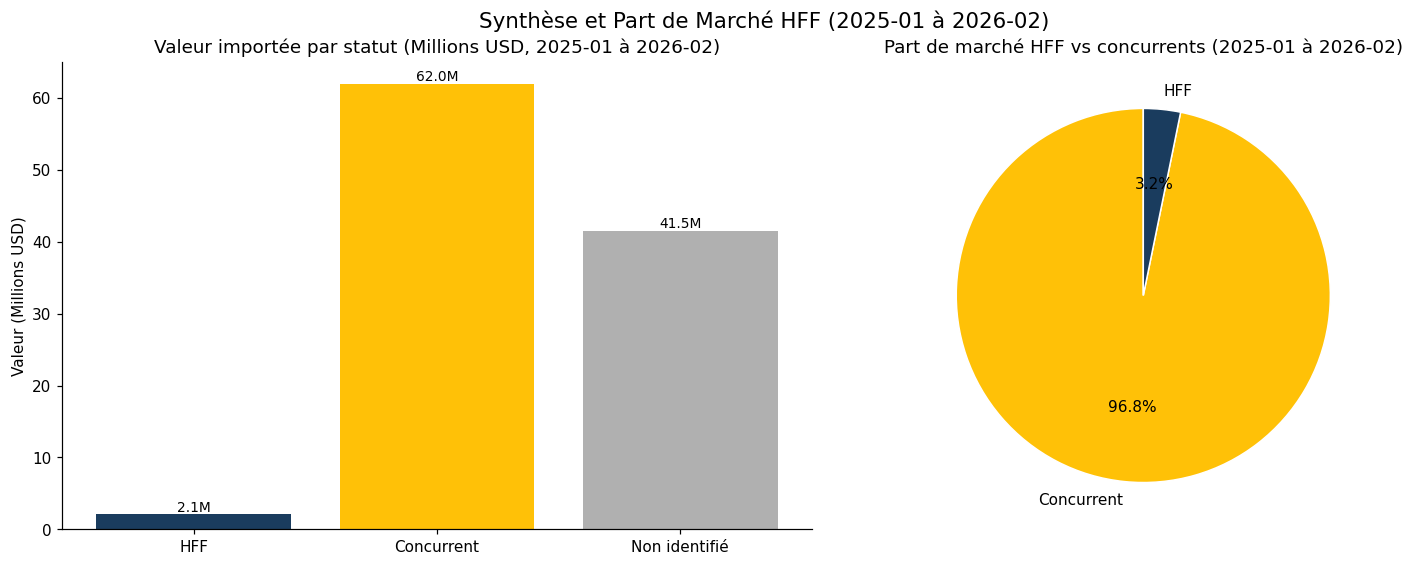



=== Analyse HFF vs Concurrents pour l'année 2025 ===

--- Synthèse par statut (2025) ---
               nb_declarations  quantite_totale  valeur_usd_totale  part_valeur_%
statut                                                                           
HFF                        223         14443.30       1.226948e+06            1.3
Concurrent                 874         27296.00       5.120134e+07           54.5
Non identifié              541          5806.69       4.150716e+07           44.2

--- Part de marché HFF vs concurrents (2025) ---
statut
Concurrent    97.7 %
HFF            2.3 %
Name: valeur_usd, dtype: object


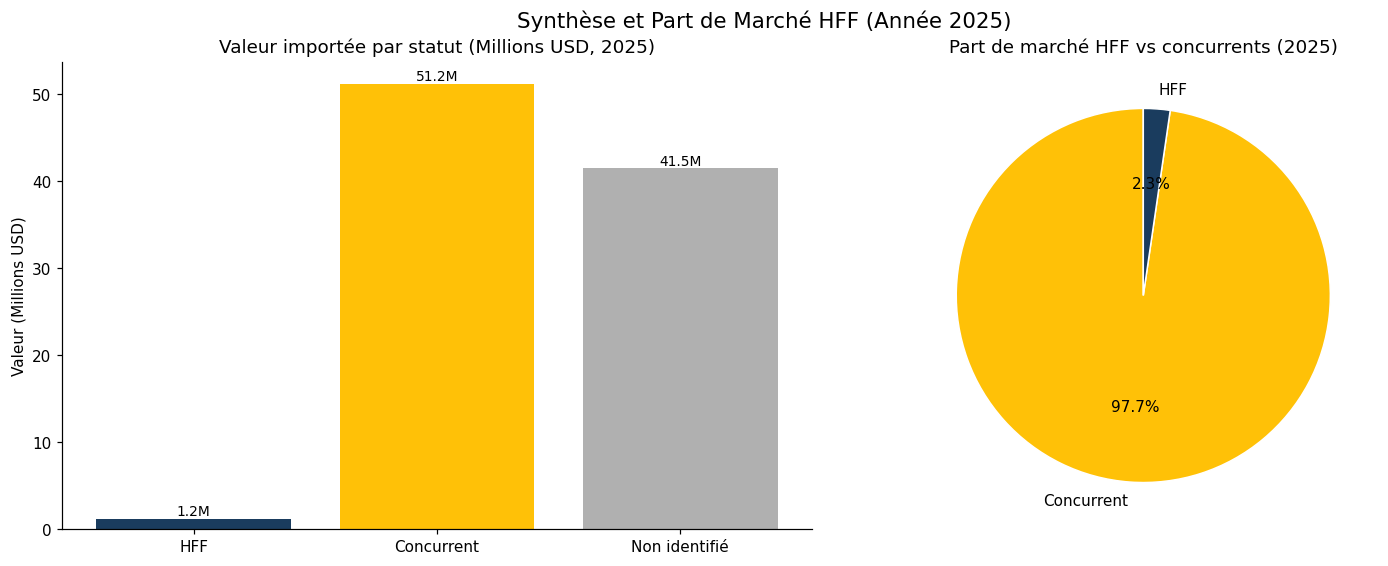



=== Analyse HFF vs Concurrents pour l'année 2026 ===

--- Synthèse par statut (2026) ---
               nb_declarations  quantite_totale  valeur_usd_totale  part_valeur_%
statut                                                                           
HFF                       39.0            831.0       8.524761e+05            7.3
Concurrent               177.0           1207.0       1.075429e+07           92.7
Non identifié              NaN              NaN                NaN            NaN

--- Part de marché HFF vs concurrents (2026) ---
statut
Concurrent    92.7 %
HFF            7.3 %
Name: valeur_usd, dtype: object


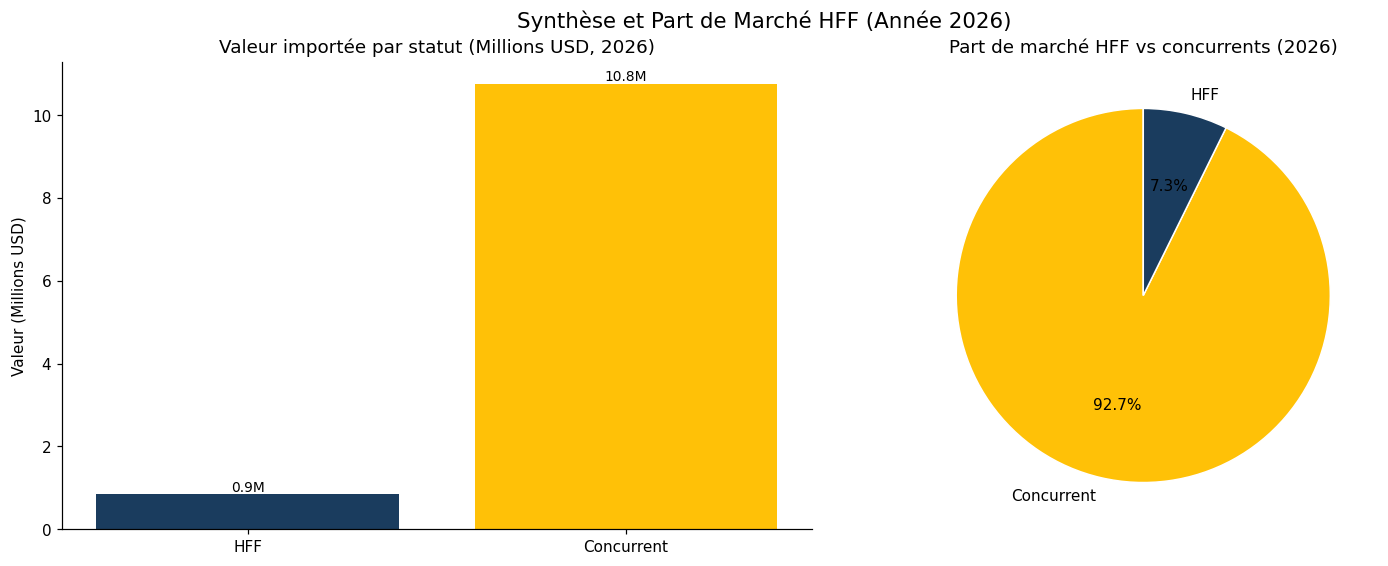



=== Analyse du marché global (2023-2024) ===
Note : Cette analyse ne permet pas de distinguer HFF des concurrents car le champ 'flag' n'est pas disponible pour cette période.


=== Analyse du marché global pour l'année 2023 ===

Synthèse globale du marché (2023) :
              nb_declarations  quantite_totale  valeur_usd_totale
Marché total              391           1556.0        20653607.44

Synthèse du marché par catégorie (2023) :
             nb_declarations  quantite_totale  valeur_usd_totale  part_valeur_%
categorie                                                                      
ENGINS                    79            622.0        10007725.18           48.5
CAMIONS                  132            516.0         6136963.95           29.7
NON CLASSE                86            236.0         2318988.38           11.2
COMPRESSEUR               48            112.0          887341.08            4.3
TRACTEUR                  29             57.0          821814.22            4.

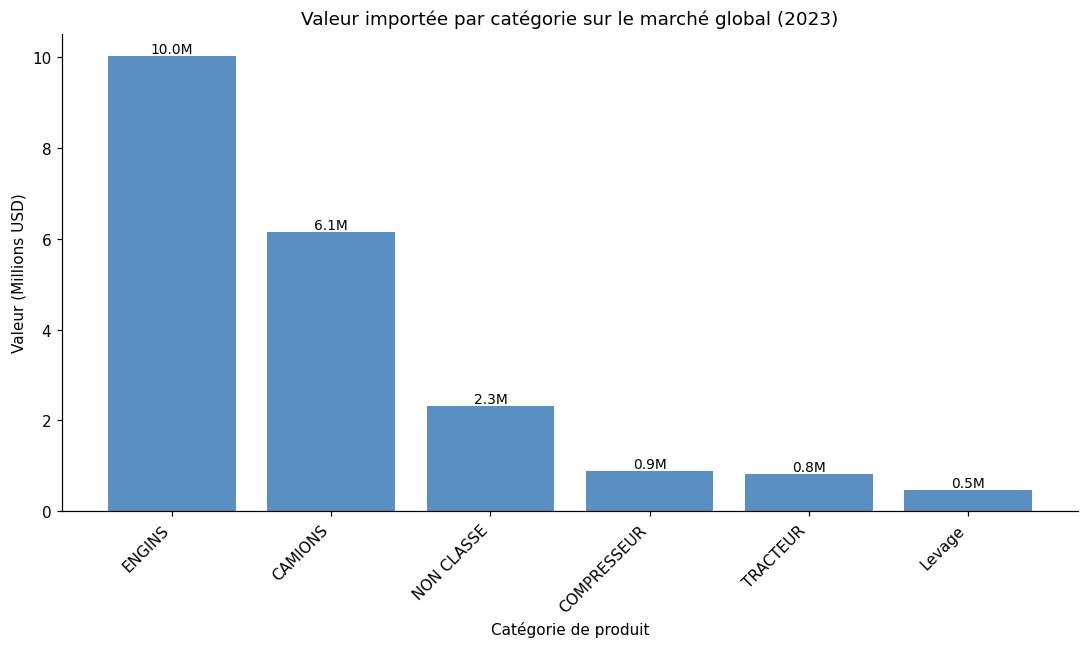



=== Analyse du marché global pour l'année 2024 ===

Synthèse globale du marché (2024) :
              nb_declarations  quantite_totale  valeur_usd_totale
Marché total              324           1542.0        35019429.52

Synthèse du marché par catégorie (2024) :
             nb_declarations  quantite_totale  valeur_usd_totale  part_valeur_%
categorie                                                                      
ENGINS                    73            463.0        12524752.11           35.8
CAMIONS                  112            621.0        11671455.72           33.3
NON CLASSE                71            249.0         6461142.23           18.5
COMPRESSEUR               29            119.0         2080250.51            5.9
Levage                    13             15.0         1330216.88            3.8
TRACTEUR                  26             75.0          951612.07            2.7


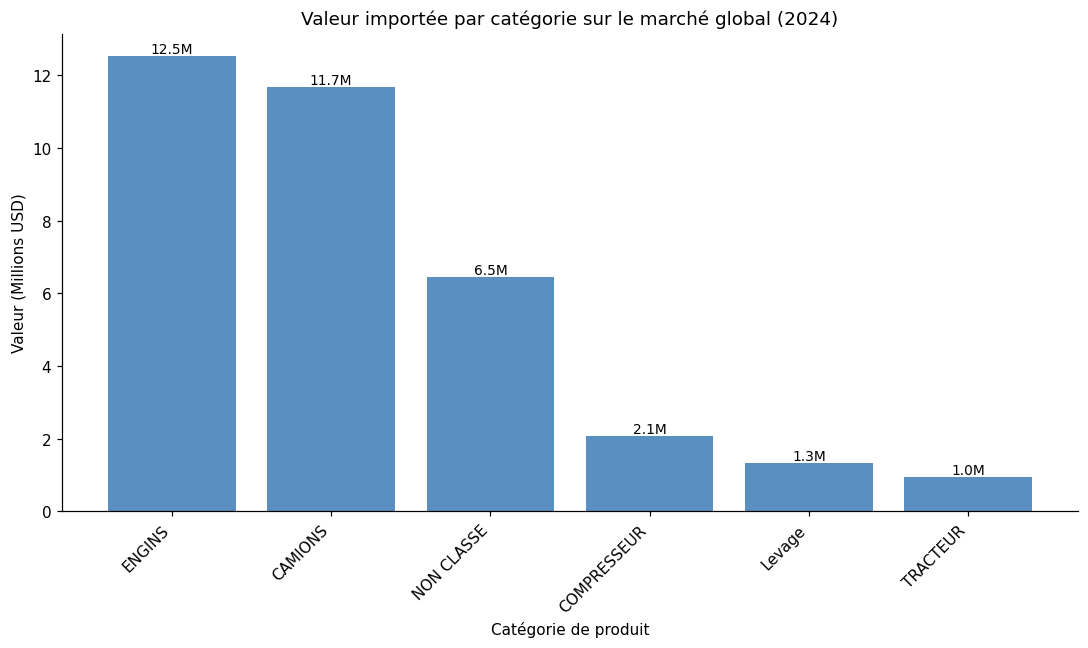

In [43]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd # Ensure pandas is imported

# Assurez-vous que OUTPUT_DIR est défini (réutilisation de la définition précédente)
OUTPUT_DIR = Path("/content/drive/MyDrive/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # S'assurer que le répertoire existe

# --- Analyse pour les données douanières 2025-2026 (HFF vs Concurrents) ---
print("=== Analyse HFF vs Concurrents (2025-01 à 2026-02) ===")

# Analyse globale 2025-2026
synthese_statut_global = (
    df_douanes.groupby("statut")
    .agg(nb_declarations=("sh_code", "count"),
         quantite_totale=("quantite", "sum"),
         valeur_usd_totale=("valeur_usd", "sum"))
    .reindex(["HFF", "Concurrent", "Non identifié"])
)
synthese_statut_global["part_valeur_%"] = (
    synthese_statut_global["valeur_usd_totale"] / synthese_statut_global["valeur_usd_totale"].sum() * 100
).round(1)

identifie_global = df_douanes[df_douanes["statut"] != "Non identifié"]
part_marche_identifie_global = (
    identifie_global.groupby("statut")["valeur_usd"].sum() / identifie_global["valeur_usd"].sum() * 100
).round(1)

print("\n--- Synthèse globale (2025-01 à 2026-02) ---")
print(synthese_statut_global)
print("\n--- Part de marché HFF vs concurrents (global) ---")
print(part_marche_identifie_global.astype(str) + " %")

# Enregistrer les DataFrames globaux dans des fichiers CSV
synthese_statut_global.to_csv(OUTPUT_DIR / "synthese_globale_statut_2025_2026.csv")
part_marche_identifie_global.to_csv(OUTPUT_DIR / "part_de_marche_hff_global_2025_2026.csv")

# Visualisation globale 2025-2026
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(synthese_statut_global.index, synthese_statut_global["valeur_usd_totale"] / 1_000_000,
            color=[COLOR_HFF, COLOR_CONCURRENT, COLOR_INCONNU])
axes[0].set_title("Valeur importée par statut (Millions USD, 2025-01 à 2026-02)")
axes[0].set_ylabel("Valeur (Millions USD)")
axes[0].ticklabel_format(style='plain', axis='y')
for i, v in enumerate(synthese_statut_global["valeur_usd_totale"] / 1_000_000):
    axes[0].text(i, v, f"{v:.1f}M", ha="center", va="bottom", fontsize=9)

axes[1].pie(part_marche_identifie_global.values, labels=part_marche_identifie_global.index,
            autopct="%1.1f%%", startangle=90,
            colors=[COLOR_CONCURRENT, COLOR_HFF] if part_marche_identifie_global.index[0] == "Concurrent" else [COLOR_HFF, COLOR_CONCURRENT],
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Part de marché HFF vs concurrents (2025-01 à 2026-02)")
plt.tight_layout()
plt.suptitle("Synthèse et Part de Marché HFF (2025-01 à 2026-02)", y=1.02, fontsize=14)
plt.show()

for year in sorted(df_douanes['reg_year'].unique()):
    print(f"\n\n=== Analyse HFF vs Concurrents pour l'année {year} ===")
    df_year = df_douanes[df_douanes['reg_year'] == year]

    if df_year.empty:
        print(f"Aucune donnée pour l'année {year}.")
        continue

    synthese_statut_an = (
        df_year.groupby("statut")
        .agg(nb_declarations=("sh_code", "count"),
             quantite_totale=("quantite", "sum"),
             valeur_usd_totale=("valeur_usd", "sum"))
        .reindex(["HFF", "Concurrent", "Non identifié"])
    )
    synthese_statut_an["part_valeur_%"] = (
        synthese_statut_an["valeur_usd_totale"] / synthese_statut_an["valeur_usd_totale"].sum() * 100
    ).round(1)

    identifie_an = df_year[df_year["statut"] != "Non identifié"]
    part_marche_identifie_an = (
        identifie_an.groupby("statut")["valeur_usd"].sum() / identifie_an["valeur_usd"].sum() * 100
    ).round(1)

    print(f"\n--- Synthèse par statut ({year}) ---")
    print(synthese_statut_an)
    print(f"\n--- Part de marché HFF vs concurrents ({year}) ---")
    print(part_marche_identifie_an.astype(str) + " %")

    # Enregistrer les DataFrames annuels dans des fichiers CSV
    synthese_statut_an.to_csv(OUTPUT_DIR / f"synthese_globale_statut_{year}.csv")
    part_marche_identifie_an.to_csv(OUTPUT_DIR / f"part_de_marche_hff_{year}.csv")

    # Visualiser les résultats annuels
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(synthese_statut_an.index, synthese_statut_an["valeur_usd_totale"] / 1_000_000,
                color=[COLOR_HFF, COLOR_CONCURRENT, COLOR_INCONNU])
    axes[0].set_title(f"Valeur importée par statut (Millions USD, {year})")
    axes[0].set_ylabel("Valeur (Millions USD)")
    axes[0].ticklabel_format(style='plain', axis='y')
    for i, v in enumerate(synthese_statut_an["valeur_usd_totale"] / 1_000_000):
        axes[0].text(i, v, f"{v:.1f}M", ha="center", va="bottom", fontsize=9)

    axes[1].pie(part_marche_identifie_an.values, labels=part_marche_identifie_an.index,
                autopct="%1.1f%%", startangle=90,
                colors=[COLOR_CONCURRENT, COLOR_HFF] if part_marche_identifie_an.index[0] == "Concurrent" else [COLOR_HFF, COLOR_CONCURRENT],
                wedgeprops={"edgecolor": "white"})
    axes[1].set_title(f"Part de marché HFF vs concurrents ({year})")

    plt.tight_layout()
    plt.suptitle(f"Synthèse et Part de Marché HFF (Année {year})", y=1.02, fontsize=14)
    plt.show()



# --- Analyse pour les données d'importation 2023-2024 (df_marche_hff) ---
print("\n\n=== Analyse du marché global (2023-2024) ===")
print("Note : Cette analyse ne permet pas de distinguer HFF des concurrents car le champ 'flag' n'est pas disponible pour cette période.")

for year in sorted(df_marche_hff['annee'].unique()):
    print(f"\n\n=== Analyse du marché global pour l'année {year} ===")
    df_marche_year = df_marche_hff[df_marche_hff['annee'] == year]

    if df_marche_year.empty:
        print(f"Aucune donnée pour l'année {year}.")
        continue

    # Synthèse globale du marché pour l'année
    synthese_marche_an = pd.DataFrame({
        'nb_declarations': [df_marche_year.shape[0]],
        'quantite_totale': [df_marche_year['quantite'].sum()],
        'valeur_usd_totale': [df_marche_year['valeur_usd'].sum()]
    }, index=['Marché total'])

    print(f"\nSynthèse globale du marché ({year}) :")
    print(synthese_marche_an.round(2))

    # Synthèse par catégorie de produit pour le marché de l'année
    marche_par_categorie_an = df_marche_year.groupby('categorie').agg(
        nb_declarations=('hs_code_8', 'count'),
        quantite_totale=('quantite', 'sum'),
        valeur_usd_totale=('valeur_usd', 'sum')
    ).sort_values('valeur_usd_totale', ascending=False)

    marche_par_categorie_an['part_valeur_%'] = (
        marche_par_categorie_an['valeur_usd_totale'] / marche_par_categorie_an['valeur_usd_totale'].sum() * 100
    ).round(1)

    print(f"\nSynthèse du marché par catégorie ({year}) :")
    print(marche_par_categorie_an.round(2))

    # Enregistrer les synthèses annuelles dans des fichiers CSV
    synthese_marche_an.to_csv(OUTPUT_DIR / f"synthese_marche_{year}.csv")
    marche_par_categorie_an.to_csv(OUTPUT_DIR / f"marche_par_categorie_{year}.csv")

    # Visualisation de la synthèse par catégorie pour l'année
    plt.figure(figsize=(10, 6))
    plt.bar(marche_par_categorie_an.index, marche_par_categorie_an['valeur_usd_totale'] / 1_000_000, color=COLOR_MARCHE)
    plt.title(f"Valeur importée par catégorie sur le marché global ({year})")
    plt.xlabel("Catégorie de produit")
    plt.ylabel("Valeur (Millions USD)")
    plt.xticks(rotation=45, ha='right')
    plt.ticklabel_format(style='plain', axis='y')
    for index, value in enumerate(marche_par_categorie_an['valeur_usd_totale'] / 1_000_000):
        plt.text(index, value, f'{value:.1f}M', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

In [44]:
# --- Statut (HFF / Concurrent / Non identifié) ---
def to_statut(flag):
    if pd.isna(flag):
        return "Non identifié"
    return "HFF" if float(flag) == 1.0 else "Concurrent"

df_douanes["statut"] = df_douanes["flag"].apply(to_statut)

# --- Catégorie produit : jointure avec le catalogue HFF, puis repli sur mots-clés ---
# Drop existing 'categorie' and 'designation_hs_code' if they exist to avoid merge conflicts on re-run
if 'categorie' in df_douanes.columns:
    df_douanes = df_douanes.drop(columns=['categorie'], errors='ignore')
if 'designation_hs_code' in df_douanes.columns:
    df_douanes = df_douanes.drop(columns=['designation_hs_code'], errors='ignore')

df_douanes = df_douanes.merge(
    catalogue_hff[["hs_code", "categorie", "description"]].rename(
        columns={"hs_code": "sh_code", "description": "designation_hs_code"}
    ),
    on="sh_code", how="left",
)
mask_non_classe = df_douanes["categorie"].isna() | (df_douanes["categorie"] == "NON CLASSE")
df_douanes.loc[mask_non_classe, "categorie"] = df_douanes.loc[mask_non_classe, "description_marchandise"].apply(guess_category)
df_douanes["categorie"] = df_douanes["categorie"].fillna("NON CLASSE")

# --- Marque ---
df_douanes["marque"] = df_douanes["description_marchandise"].apply(extract_brand)

# --- Normalisation devise : taux de change USD/MGA mensuel de référence (moyenne des
#     déclarations en USD du mois), utilisé pour convertir toutes les valeurs en USD ---
taux_usd_mensuel = (
    df_douanes.loc[df_douanes["DEVISE"] == "USD"]
    .groupby(["reg_year", "month"])["TAUXCHANGE"].mean()
)
def to_usd(row):
    key = (row["reg_year"], row["month"])
    taux = taux_usd_mensuel.get(key, np.nan)
    if pd.isna(taux) or taux == 0:
        taux = df_douanes["TAUXCHANGE"].median()
    return row["amount_ariary"] / taux

df_douanes["valeur_usd"] = df_douanes.apply(to_usd, axis=1)
df_douanes["quantite"] = df_douanes["number_of_units"].fillna(0)

# --- Nettoyage description (retrait des points/tirets de remplissage douanier) ---
df_douanes["description_clean"] = (
    df_douanes["description_marchandise"].fillna("")
    .str.replace(r"[.\-]{2,}", "", regex=True)
    .str.strip()
)

print("Dataset normalisé :", df_douanes.shape)
print()
print(df_douanes["statut"].value_counts())
print()
print(df_douanes[["reg_date", "sh_code", "categorie", "marque", "statut", "amount_ariary", "valeur_usd", "DEVISE"]].head(8))

Dataset normalisé : (1854, 30)

statut
Concurrent       1051
Non identifié     541
HFF               262
Name: count, dtype: int64

    reg_date   sh_code    categorie                 marque statut  amount_ariary    valeur_usd DEVISE
0 2025-01-03  84144000  COMPRESSEUR  Marque non identifiée    HFF        1610858    343.380790    EUR
1 2025-01-07  84144000  COMPRESSEUR  Marque non identifiée    HFF         381646     81.354101    EUR
2 2025-01-08  84144000  COMPRESSEUR  Marque non identifiée    HFF         545406    116.262230    USD
3 2025-01-08  84144000  COMPRESSEUR  Marque non identifiée    HFF       14060632   2997.254212    USD
4 2025-01-10  84144000  COMPRESSEUR  Marque non identifiée    HFF       83747444  17852.140592    USD
5 2025-01-10  84144000  COMPRESSEUR  Marque non identifiée    HFF      138150119  29448.962612    USD
6 2025-01-13  84144000  COMPRESSEUR  Marque non identifiée    HFF        7357903   1568.457645    USD
7 2025-01-14  84144000  COMPRESSEUR  Marque non iden

### 4.2 Positionnement par catégorie de produit

In [45]:
pivot_categorie = pd.pivot_table(
    identifie_global, index="categorie", columns="statut", values="valeur_usd",
    aggfunc="sum", fill_value=0,
)
pivot_categorie["Total"] = pivot_categorie.sum(axis=1)
pivot_categorie["Part HFF %"] = (pivot_categorie.get("HFF", 0) / pivot_categorie["Total"] * 100).round(1)
pivot_categorie = pivot_categorie.sort_values("Total", ascending=False)

print("=== Valeur importée (USD, approx.) par catégorie et statut ===")
print(pivot_categorie.round(0))

=== Valeur importée (USD, approx.) par catégorie et statut ===
statut       Concurrent        HFF       Total  Part HFF %
categorie                                                 
CAMIONS      26659610.0    33046.0  26692656.0         0.0
G E          18074820.0        0.0  18074820.0         0.0
ENGINS       13793777.0        0.0  13793777.0         0.0
Levage        1973298.0  1293415.0   3266714.0        40.0
TRACTEUR      1454128.0        0.0   1454128.0         0.0
COMPRESSEUR         0.0   656593.0    656593.0       100.0
NON CLASSE          0.0    96369.0     96369.0       100.0


### 4.3 Positionnement par marque

In [46]:
# Positionnement HFF par marque : on exclut "Marque non identifiée" du classement des
# marques concurrentes (description trop générique pour être exploitable), mais on la
# garde visible séparément pour information.
marques_identifiees = identifie_global[identifie_global["marque"] != "Marque non identifiée"]

pivot_marque = pd.pivot_table(
    marques_identifiees, index="marque", columns="statut", values="valeur_usd",
    aggfunc="sum", fill_value=0,
)
pivot_marque["Total"] = pivot_marque.sum(axis=1)
pivot_marque["Part HFF %"] = (pivot_marque.get("HFF", 0) / pivot_marque["Total"] * 100).round(1)
pivot_marque = pivot_marque.sort_values("Total", ascending=False)

print(f"Marques identifiées dans les descriptions : {pivot_marque.shape[0]}")
print(f"Part des déclarations avec marque non identifiable : "
      f"{(identifie_global['marque'] == 'Marque non identifiée').mean() * 100:.1f}%")
print()
print("=== Top 15 marques par valeur totale importée (USD, approx.) ===")
print(pivot_marque.head(15).round(0))
print()
print("=== Marques sur lesquelles HFF est positionnée ===")
print(pivot_marque[pivot_marque.get("HFF", 0) > 0].round(0))

Marques identifiées dans les descriptions : 30
Part des déclarations avec marque non identifiable : 81.8%

=== Top 15 marques par valeur totale importée (USD, approx.) ===
statut           Concurrent      HFF      Total  Part HFF %
marque                                                     
Sinotruk (Howo)   7258460.0      0.0  7258460.0         0.0
Caterpillar       7104569.0      0.0  7104569.0         0.0
Foton             2931346.0      0.0  2931346.0         0.0
FAW               2492872.0      0.0  2492872.0         0.0
Mercedes-Benz      730479.0      0.0   730479.0         0.0
Hitachi            541383.0      0.0   541383.0         0.0
FG Wilson          446545.0      0.0   446545.0         0.0
SEM                390218.0      0.0   390218.0         0.0
Hyster             285972.0   5732.0   291704.0         2.0
Renault            228698.0      0.0   228698.0         0.0
Komatsu            220864.0      0.0   220864.0         0.0
Zoomlion           148290.0  55084.0   203374.0 

### 4.4 Évolution temporelle

In [48]:
identifie2 = identifie_global.copy()
identifie2["periode"] = identifie2["reg_date"].dt.to_period("M").astype(str)

evolution_mensuelle = pd.pivot_table(
    identifie2, index="periode", columns="statut", values="valeur_usd",
    aggfunc="sum", fill_value=0,
).sort_index()
evolution_mensuelle["Part HFF %"] = (
    evolution_mensuelle.get("HFF", 0) / evolution_mensuelle.sum(axis=1) * 100
).round(1)

print("=== Évolution mensuelle de la valeur importée (USD, approx.) ===")
print(evolution_mensuelle.round(0))

=== Évolution mensuelle de la valeur importée (USD, approx.) ===
statut   Concurrent       HFF  Part HFF %
periode                                  
2025-01  11495988.0  109272.0         1.0
2025-03   6253432.0   13586.0         0.0
2025-04   8500351.0  169061.0         2.0
2025-05   6398116.0  270740.0         4.0
2025-06   9924246.0  261657.0         3.0
2025-11   3022044.0  255082.0         8.0
2025-12   5607162.0  147551.0         3.0
2026-01   7659346.0  132060.0         2.0
2026-02   3094948.0  720416.0        19.0


### 4.5 Analyse par pays d'origine

In [50]:
pivot_origine = pd.pivot_table(
    identifie_global, index="origine_libelle", columns="statut", values="valeur_usd",
    aggfunc="sum", fill_value=0,
)
pivot_origine["Total"] = pivot_origine.sum(axis=1)
pivot_origine = pivot_origine.sort_values("Total", ascending=False).head(10)

print("=== Top 10 pays d'origine par valeur importée (USD, approx.) ===")
print(pivot_origine.round(0))

=== Top 10 pays d'origine par valeur importée (USD, approx.) ===
statut                Concurrent        HFF       Total
origine_libelle                                        
CHINE                 45930632.0  1063430.0  46994062.0
INDE                   3016385.0   118661.0   3135046.0
ALLEMAGNE              2044874.0   594568.0   2639442.0
FRANCE                 2342691.0   122945.0   2465637.0
COREE, REPUBLIQUE DE   1521671.0    11527.0   1533198.0
EMIRATS ARABES UNIS    1497111.0     2903.0   1500014.0
ETATS-UNIS             1250246.0     3888.0   1254135.0
AFRIQUE DU SUD         1070667.0     2296.0   1072963.0
MALAISIE                648691.0        0.0    648691.0
TURQUIE                 538414.0        0.0    538414.0


## 5. Visualisations

Cinq graphiques de synthèse : répartition globale, top marques, évolution mensuelle,
positionnement par catégorie et carte de chaleur marque × catégorie.


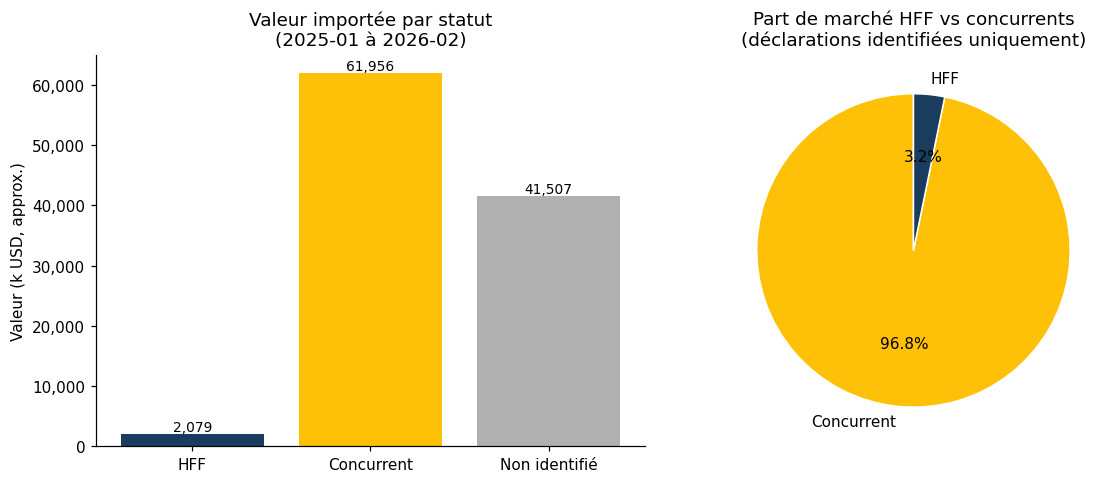

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# (a) répartition globale valeur incluant "Non identifié"
axes[0].bar(
    synthese_statut_global.index, synthese_statut_global["valeur_usd_totale"] / 1000,
    color=[COLOR_HFF, COLOR_CONCURRENT, COLOR_INCONNU],
)
axes[0].set_title("Valeur importée par statut\n(2025-01 à 2026-02)")
axes[0].set_ylabel("Valeur (k USD, approx.)")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
for i, v in enumerate(synthese_statut_global["valeur_usd_totale"] / 1000):
    axes[0].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

# (b) part de marché HFF vs concurrents (hors non identifié)
axes[1].pie(
    part_marche_identifie_global.values, labels=part_marche_identifie_global.index,
    autopct="%1.1f%%", colors=[COLOR_CONCURRENT, COLOR_HFF]
    if part_marche_identifie_global.index[0] == "Concurrent" else [COLOR_HFF, COLOR_CONCURRENT],
    startangle=90, wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Part de marché HFF vs concurrents\n(déclarations identifiées uniquement)")

plt.tight_layout()
plt.savefig("chart1_part_marche.png", bbox_inches="tight")
plt.show()

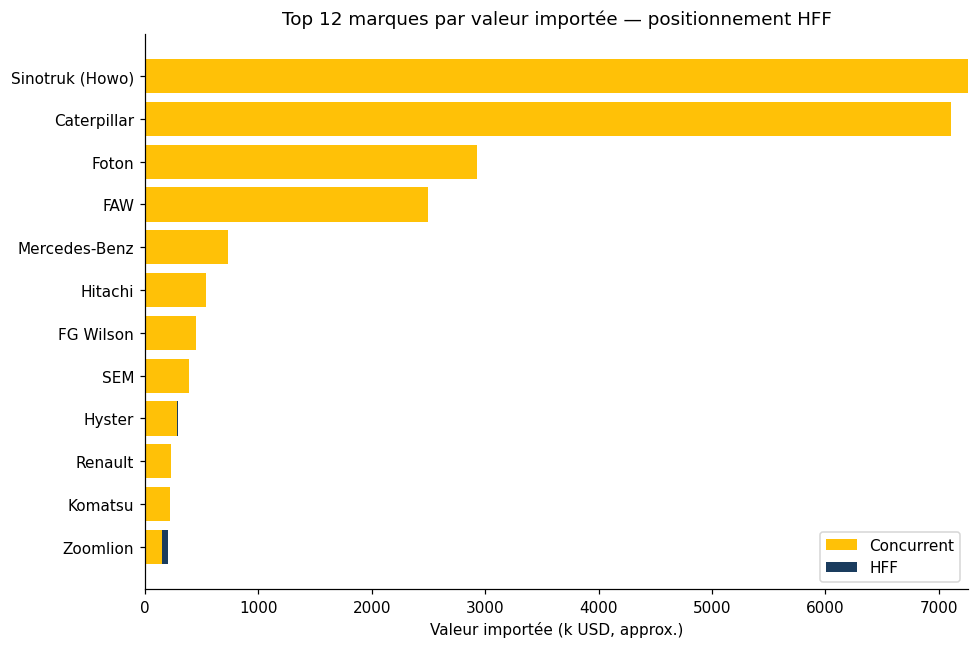

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Redefine marques_identifiees and pivot_marque within this cell to ensure they are available
marques_identifiees = identifie_global[identifie_global["marque"] != "Marque non identifiée"]

pivot_marque = pd.pivot_table(
    marques_identifiees, index="marque", columns="statut", values="valeur_usd",
    aggfunc="sum", fill_value=0,
)
pivot_marque["Total"] = pivot_marque.sum(axis=1)
pivot_marque["Part HFF %"] = (pivot_marque.get("HFF", 0) / pivot_marque["Total"] * 100).round(1)
pivot_marque = pivot_marque.sort_values("Total", ascending=False)

top_marques = pivot_marque.head(12).sort_values("Total")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_marques.index, top_marques.get("Concurrent", 0) / 1000, color=COLOR_CONCURRENT, label="Concurrent")
ax.barh(top_marques.index, top_marques.get("HFF", 0) / 1000,
        left=top_marques.get("Concurrent", 0) / 1000, color=COLOR_HFF, label="HFF")
ax.set_xlabel("Valeur importée (k USD, approx.)")
ax.set_title("Top 12 marques par valeur importée — positionnement HFF")
ax.legend()
plt.tight_layout()
plt.savefig("chart2_top_marques.png", bbox_inches="tight")
plt.show()

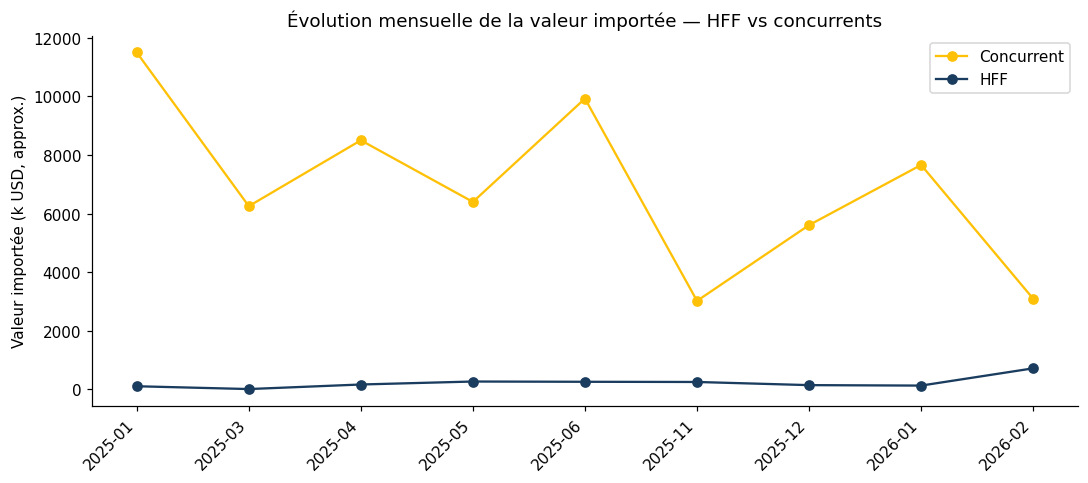

In [55]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(evolution_mensuelle.index, evolution_mensuelle.get("Concurrent", 0) / 1000,
        marker="o", color=COLOR_CONCURRENT, label="Concurrent")
ax.plot(evolution_mensuelle.index, evolution_mensuelle.get("HFF", 0) / 1000,
        marker="o", color=COLOR_HFF, label="HFF")
ax.set_ylabel("Valeur importée (k USD, approx.)")
ax.set_title("Évolution mensuelle de la valeur importée — HFF vs concurrents")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart3_evolution.png", bbox_inches="tight")
plt.show()


### Confirmation de la tendance 2026 par l'évolution mensuelle

En analysant l'évolution mensuelle, on constate que la part de marché de HFF, qui était de 2% en janvier 2026, a fortement augmenté pour atteindre **19% en février 2026**. Cela confirme la tendance d'une part de marché relativement plus élevée pour HFF sur cette courte période de l'année 2026 par rapport à la moyenne de 2025.

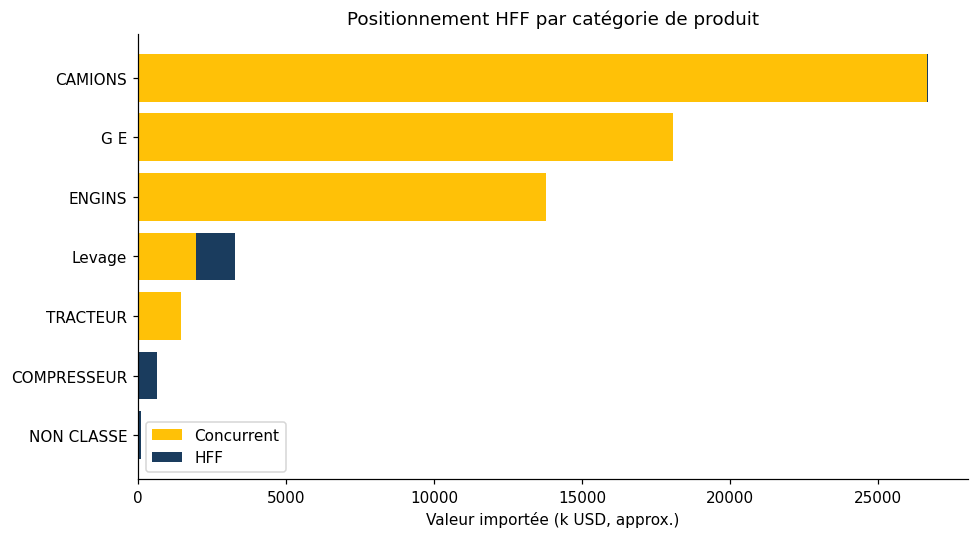

In [56]:
cat_sorted = pivot_categorie.sort_values("Total")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cat_sorted.index, cat_sorted.get("Concurrent", 0) / 1000, color=COLOR_CONCURRENT, label="Concurrent")
ax.barh(cat_sorted.index, cat_sorted.get("HFF", 0) / 1000,
        left=cat_sorted.get("Concurrent", 0) / 1000, color=COLOR_HFF, label="HFF")
ax.set_xlabel("Valeur importée (k USD, approx.)")
ax.set_title("Positionnement HFF par catégorie de produit")
ax.legend()
plt.tight_layout()
plt.savefig("chart4_par_categorie.png", bbox_inches="tight")
plt.show()


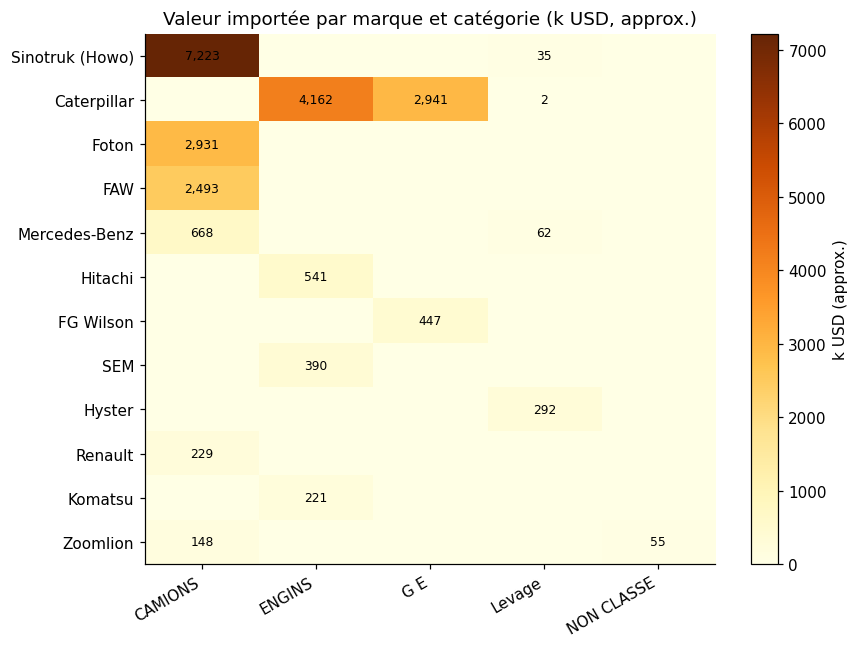

In [57]:
top_marques_list = pivot_marque.head(12).index.tolist()
heat_data = pd.pivot_table(
    marques_identifiees[marques_identifiees["marque"].isin(top_marques_list)],
    index="marque", columns="categorie", values="valeur_usd", aggfunc="sum", fill_value=0,
).reindex(top_marques_list) / 1000

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat_data.values, cmap="YlOrBr", aspect="auto")
ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)
ax.set_title("Valeur importée par marque et catégorie (k USD, approx.)")
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        v = heat_data.values[i, j]
        if v > 0:
            ax.text(j, i, f"{v:,.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="k USD (approx.)")
plt.tight_layout()
plt.savefig("chart5_heatmap_marque_categorie.png", bbox_inches="tight")
plt.show()


## 6. Génération du fichier résultat Excel

Le classeur `HFF_Analyse_Positionnement_Concurrentiel.xlsx` est généré avec 5 feuilles :
`Synthese`, `Par_marque`, `Evolution_mensuelle`, `Donnees_consolidees` (détail ligne à ligne) et
`Graphiques`.


In [59]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter

# Updated OUT_PATH to save to Google Drive
OUT_PATH = "/content/drive/MyDrive/outputs/HFF_Analyse_Positionnement_Concurrentiel.xlsx"

HEADER_FILL = PatternFill("solid", fgColor="1A3C5E")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF")
TITLE_FONT = Font(name="Arial", bold=True, size=14, color="1A3C5E")
BODY_FONT = Font(name="Arial", size=10)

def write_df(ws, df, start_row=1, index=True, title=None):
    r = start_row
    if title:
        ws.cell(row=r, column=1, value=title).font = TITLE_FONT
        r += 2
    df_reset = df.reset_index() if index else df
    for j, col in enumerate(df_reset.columns, start=1):
        c = ws.cell(row=r, column=j, value=str(col))
        c.font = HEADER_FONT
        c.fill = HEADER_FILL
        c.alignment = Alignment(horizontal="center")
    for i, row in enumerate(dataframe_to_rows(df_reset, index=False, header=False), start=r + 1):
        for j, val in enumerate(row, start=1):
            cell = ws.cell(row=i, column=j, value=val)
            cell.font = BODY_FONT
    for j, col in enumerate(df_reset.columns, start=1):
        width = max(12, min(40, int(df_reset[col].astype(str).str.len().max() if len(df_reset) else 12) + 2))
        ws.column_dimensions[get_column_letter(j)].width = width
    return r + len(df_reset) + 1

wb = Workbook()

# --- Feuille 1 : Synthèse ---
ws1 = wb.active
ws1.title = "Synthese"
ws1["A1"] = "Analyse du positionnement concurrentiel HFF — Matériels divers, engins, véhicules"
ws1["A1"].font = Font(name="Arial", bold=True, size=15, color="1A3C5E")
ws1["A2"] = "Période couverte : Janvier 2023 - Février 2026 (import données douanes Madagascar)"
ws1["A2"].font = Font(name="Arial", italic=True, size=10)
next_row = write_df(ws1, synthese_statut_global, start_row=4, title="1. Synthèse globale par statut (2025-01 à 2026-02)")
next_row = write_df(ws1, pivot_categorie, start_row=next_row + 1, title="2. Positionnement par catégorie de produit")
next_row = write_df(ws1, pivot_origine, start_row=next_row + 1, title="3. Top 10 pays d'origine")

# --- Feuille 2 : Par marque ---
ws2 = wb.create_sheet("Par_marque")
write_df(ws2, pivot_marque, start_row=1, title="Positionnement HFF par marque (hors marque non identifiée)")

# --- Feuille 3 : Évolution mensuelle ---
ws3 = wb.create_sheet("Evolution_mensuelle")
write_df(ws3, evolution_mensuelle, start_row=1, title="Évolution mensuelle de la valeur importée (USD, approx.)")

# --- Feuille 4 : Données consolidées (détail) ---
ws4 = wb.create_sheet("Donnees_consolidees")
detail_cols = [
    "reg_date", "source_periode", "sh_code", "categorie", "marque", "description_clean",
    "statut", "quantite", "amount_ariary", "DEVISE", "valeur_usd",
    "provenance_libelle", "origine_libelle", "regime_libelle",
]
detail = df_douanes[detail_cols].sort_values("reg_date").rename(columns={
    "reg_date": "Date", "source_periode": "Période source", "sh_code": "HS Code",
    "categorie": "Catégorie", "marque": "Marque", "description_clean": "Désignation",
    "statut": "Statut", "quantite": "Quantité", "amount_ariary": "Valeur (Ariary)",
    "DEVISE": "Devise déclarée", "valeur_usd": "Valeur (USD, approx.)",
    "provenance_libelle": "Provenance", "origine_libelle": "Origine", "regime_libelle": "Régime douanier",
})
write_df(ws4, detail, start_row=1, index=False, title="Détail des déclarations douanières (2025-01 à 2026-02)")

# --- Feuille 5 : Graphiques ---
ws5 = wb.create_sheet("Graphiques")
from openpyxl.drawing.image import Image as XLImage
row_cursor = 1
for png in ["chart1_part_marche.png", "chart2_top_marques.png", "chart3_evolution.png",
            "chart4_par_categorie.png", "chart5_heatmap_marque_categorie.png"]:
    img = XLImage(png)
    img.width, img.height = img.width * 0.75, img.height * 0.75
    ws5.add_image(img, f"A{row_cursor}")
    row_cursor += int(img.height / 15) + 2

wb.save(OUT_PATH)
print("Fichier résultat enregistré :", OUT_PATH)

Fichier résultat enregistré : /content/drive/MyDrive/outputs/HFF_Analyse_Positionnement_Concurrentiel.xlsx


## 7. Synthèse et limites de l'analyse

**Constats clés (2025-01 à 2026-02, déclarations identifiées) :**
- HFF représente environ **3 % de part de marché en valeur** sur le périmètre des HS codes suivis.
- HFF n'apparaît que sur les catégories **Compresseur** et **Levage** (marques Atlas Copco, Hyster,
  Zoomlion) ; elle est absente des catégories Camions, Engins, Groupes électrogènes et Tracteurs
  sur la période analysée.
- Les concurrents dominants en valeur sont **Sinotruk (Howo)**, **Caterpillar**, **Foton** et
  **FAW**, principalement sur Camions et Engins.
- La Chine est de loin le premier pays d'origine, tous statuts confondus.

**Limites à garder à l'esprit :**
- Le champ `flag` n'est pas renseigné pour 541 déclarations du fichier "HS Code 2025" (39 % de la
  valeur totale) : le calcul de part de marché exclut ces lignes "Non identifié" pour ne comparer
  que les déclarations attribuées avec certitude.
- La marque n'a pu être identifiée dans le texte libre de la description que pour **18 %**
  des déclarations identifiées (HFF + Concurrent) : le classement par marque est donc partiel et
  probablement biaisé en faveur des marques dont le nom apparaît explicitement en douane.
- La valeur en USD est une **approximation** (taux de change mensuel moyen), la valeur en Ariary
  restant la référence officielle de la déclaration douanière.
- Le fichier "Imports 2023-2024" (marché global) ne comporte pas de champ `flag` et n'a donc pas
  pu être intégré à la comparaison HFF/concurrents ; il sert uniquement de repère de marché.

**Pistes d'amélioration possibles :** compléter le marquage `flag` des 541 déclarations non
identifiées, enrichir le dictionnaire de marques pour réduire la part "Marque non identifiée", et
si possible croiser avec un fichier "opérateur/importateur" pour fiabiliser l'identification HFF
vs concurrents au-delà du texte libre.
